# Computer Exercise 12.3 — Problem 2

> **교재**: Cheney & Kincaid, *Numerical Mathematics and Computing* (7th ed.)
> **단원**: 12. Partial Differential Equations · **절**: §12.3 Elliptic Problems (Poisson / Laplace)
> **주제**: 같은 2D 푸아송 계를 **반복법(Jacobi · Gauss–Seidel · SOR)** 으로 풀고, 수렴속도·반복횟수·**최적 완화계수 $\omega^*$** 비교
> **풀이 일자**: 2026-06-17 · **언어**: 한국어(본문) / English(그래프 라벨)

## 1. 문제 (원문)

> For the discrete Poisson system $-\nabla_h^2 u = f$ on the unit square with homogeneous
> Dirichlet data (five-point stencil), implement the three classical **stationary iterative
> methods** — **Jacobi**, **Gauss–Seidel**, and **successive over-relaxation (SOR)** — in a
> *matrix-free* form that updates the grid in place. Compare the number of iterations each
> needs to reduce the residual below a fixed tolerance, plot the residual histories, and find
> the **optimal relaxation parameter** $\omega^*$ for SOR. Compare the observed iteration
> counts and spectral radii against the classical theory.

### 한국어 풀이용 정리
- 문제 1의 5점 차분계를 **행렬을 만들지 않고** 격자 위에서 직접 반복으로 푼다.
- 세 방법의 **반복 횟수**(잔차 $<$ tol)와 **잔차 이력**(semilog)을 비교.
- SOR의 **최적 $\omega^*=2/(1+\sin\pi h)$** 를 스캔으로 찾아 이론과 대조.
- 제조해 $u^*=\sin\pi x\sin\pi y$, $f=2\pi^2\sin\pi x\sin\pi y$ (문제 1과 동일).

## 2. 수학적 배경

### 2.1 점별 갱신식 (5점 스텐실)
$4u_{i,j}=u_{i-1,j}+u_{i+1,j}+u_{i,j-1}+u_{i,j+1}+h^2f_{i,j}$ 이므로 각 방법은
$$ \text{Jacobi: } u_{i,j}^{(k+1)}=\tfrac14\big(u_{i\pm1,j}^{(k)}+u_{i,j\pm1}^{(k)}+h^2f_{i,j}\big), $$
$$ \text{Gauss–Seidel: 같은 식이되 *최신값* 즉시 사용(순차 sweep)}, $$
$$ \text{SOR: } u_{i,j}^{(k+1)}=(1-\omega)\,u_{i,j}^{(k)}+\omega\,u_{i,j}^{\text{GS}}. $$

### 2.2 수렴인자(스펙트럼 반경) — 정사각형 모형
격자간격 $h=1/M$ 에서 고전 결과:
$$ \boxed{\;\rho_{\text{Jac}}=\cos\pi h,\quad \rho_{\text{GS}}=\cos^2\pi h,\quad
   \omega^*=\frac{2}{1+\sin\pi h},\quad \rho_{\text{SOR}}=\omega^*-1.\;} $$
$h$ 가 작아질수록 $\rho_{\text{Jac}},\rho_{\text{GS}}\to1$ (느림, 반복 $\sim\mathcal{O}(M^2)$),
그러나 최적 SOR 은 $\rho_{\text{SOR}}\approx1-2\pi h$ 로 **반복 $\sim\mathcal{O}(M)$** — 한 차수 빠르다.

### 2.3 잔차
잔차 $r_{i,j}=h^2f_{i,j}-(4u_{i,j}-\text{이웃합})$ 의 무한노름이 tol 밑으로 내려갈 때까지 반복.

## 3. 풀이 흐름

1. 격자 $M=32$, 제조해/강제항 정의 (문제 1과 동일).
2. Jacobi(벡터화), Gauss–Seidel(순차 sweep), SOR(완화) 를 하나의 함수로 구현, 잔차 이력 기록.
3. 각 방법을 같은 tol($10^{-8}$)까지 돌려 **반복 횟수**와 정확해 대비 오차 기록.
4. $\omega\in[1.0,1.99]$ 스캔으로 SOR 반복 횟수 최소가 되는 $\omega$ 를 찾고 이론 $\omega^*$ 와 비교.
5. 이론 스펙트럼 반경 vs 관측 평균 수렴인자 표로 대조.
6. 시각화: (좌) 세 방법 잔차 이력 semilog, (우) SOR 반복수 vs $\omega$.
7. 결과 해석: GS 가 Jacobi 의 ~2배 빠름, 최적 SOR 이 차수적으로 우월함을 정량 확인.

In [1]:
%matplotlib inline

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
pd.set_option("display.float_format", lambda v: f"{v:.6e}")

M = 32
h = 1.0/M
xi = np.linspace(0,1,M+1)
X, Y = np.meshgrid(xi, xi, indexing="ij")
F = 2*np.pi**2*np.sin(np.pi*X)*np.sin(np.pi*Y)
U_exact = np.sin(np.pi*X)*np.sin(np.pi*Y)

def residual(u):
    r = np.zeros_like(u)
    r[1:-1,1:-1] = (h**2)*F[1:-1,1:-1] - (4*u[1:-1,1:-1]
                    - u[:-2,1:-1] - u[2:,1:-1] - u[1:-1,:-2] - u[1:-1,2:])
    return np.max(np.abs(r))

def solve_iter(method, omega=1.0, tol=1e-8, maxit=20000):
    u = np.zeros((M+1, M+1))      # 경계 0 포함, 동차 Dirichlet
    hist = []
    for k in range(1, maxit+1):
        if method == "jacobi":
            un = u.copy()
            un[1:-1,1:-1] = 0.25*(u[:-2,1:-1]+u[2:,1:-1]+u[1:-1,:-2]+u[1:-1,2:]
                                  + (h**2)*F[1:-1,1:-1])
            u = un
        else:  # gauss-seidel / sor (순차 sweep, 최신값 사용)
            for i in range(1, M):
                for j in range(1, M):
                    gs = 0.25*(u[i-1,j]+u[i+1,j]+u[i,j-1]+u[i,j+1] + (h**2)*F[i,j])
                    u[i,j] = (1-omega)*u[i,j] + omega*gs
        res = residual(u)
        hist.append(res)
        if res < tol:
            break
    return u, k, np.array(hist)

# 이론값
rho_jac = np.cos(np.pi*h)
rho_gs  = np.cos(np.pi*h)**2
omega_opt = 2/(1+np.sin(np.pi*h))
rho_sor = omega_opt - 1
print(f"M={M}, h={h:.4e}")
print(f"theory: rho_Jac={rho_jac:.5f}  rho_GS={rho_gs:.5f}  omega*={omega_opt:.5f}  rho_SOR={rho_sor:.5f}")

M=32, h=3.1250e-02
theory: rho_Jac=0.99518  rho_GS=0.99039  omega*=1.82147  rho_SOR=0.82147


In [3]:
# 세 방법 비교 (같은 tol)
uJ, kJ, hJ = solve_iter("jacobi")
uG, kG, hG = solve_iter("gs", omega=1.0)
uS, kS, hS = solve_iter("sor", omega=omega_opt)

def avg_factor(hist):
    # 후반부 평균 수렴인자 (잔차비의 기하평균)
    h2 = hist[len(hist)//2:]
    return (h2[-1]/h2[0])**(1/(len(h2)-1)) if len(h2) > 2 else np.nan

rows = [
    ("Jacobi",        kJ, np.max(np.abs(uJ-U_exact)), avg_factor(hJ), rho_jac),
    ("Gauss-Seidel",  kG, np.max(np.abs(uG-U_exact)), avg_factor(hG), rho_gs),
    (f"SOR(w*={omega_opt:.3f})", kS, np.max(np.abs(uS-U_exact)), avg_factor(hS), rho_sor),
]
comp = pd.DataFrame(rows, columns=["method","iters","sol_error","obs_factor","theory_rho"])
comp

,method,iters,sol_error,obs_factor,theory_rho
0,Jacobi,2999,8.030606e-04,9.951847e-01,9.951847e-01
1,Gauss-Seidel,1501,8.030664e-04,9.903926e-01,9.903926e-01
2,SOR(w*=1.821),101,8.035118e-04,8.102733e-01,8.214652e-01


In [4]:
# SOR: omega 스캔으로 최적값 탐색
omegas = np.round(np.arange(1.0, 1.99, 0.02), 3)
iters = []
for w in omegas:
    _, k, _ = solve_iter("sor", omega=w, tol=1e-8, maxit=5000)
    iters.append(k)
iters = np.array(iters)
w_best = omegas[np.argmin(iters)]
scan = pd.DataFrame({"omega": omegas, "iters": iters})
print(f"observed best omega = {w_best:.3f} (min iters={iters.min()}),  theory omega* = {omega_opt:.3f}")
scan.iloc[::6]

observed best omega = 1.820 (min iters=104),  theory omega* = 1.821


,omega,iters
0,1.000000e+00,1501
6,1.120000e+00,1178
12,1.240000e+00,917
18,1.360000e+00,702
24,1.480000e+00,521
30,1.600000e+00,366
36,1.720000e+00,228
42,1.840000e+00,108
48,1.960000e+00,418


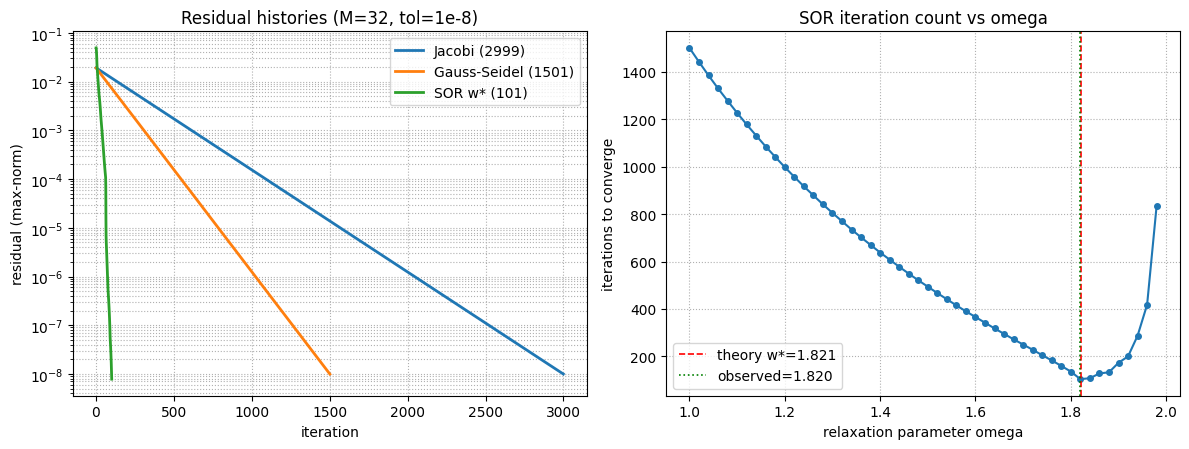

In [5]:
# 시각화: (좌) 잔차 이력 semilog, (우) SOR 반복수 vs omega
fig, ax = plt.subplots(1, 2, figsize=(12, 4.6))
ax[0].semilogy(np.arange(1,len(hJ)+1), hJ, lw=2, label=f"Jacobi ({kJ})")
ax[0].semilogy(np.arange(1,len(hG)+1), hG, lw=2, label=f"Gauss-Seidel ({kG})")
ax[0].semilogy(np.arange(1,len(hS)+1), hS, lw=2, label=f"SOR w* ({kS})")
ax[0].set_xlabel("iteration"); ax[0].set_ylabel("residual (max-norm)")
ax[0].set_title("Residual histories (M=32, tol=1e-8)")
ax[0].legend(); ax[0].grid(True, which="both", ls=":")

ax[1].plot(omegas, iters, "o-", lw=1.5, ms=4)
ax[1].axvline(omega_opt, color="r", ls="--", lw=1.2, label=f"theory w*={omega_opt:.3f}")
ax[1].axvline(w_best, color="g", ls=":", lw=1.2, label=f"observed={w_best:.3f}")
ax[1].set_xlabel("relaxation parameter omega"); ax[1].set_ylabel("iterations to converge")
ax[1].set_title("SOR iteration count vs omega")
ax[1].legend(); ax[1].grid(True, ls=":")
plt.tight_layout(); plt.show()

## 4. 결과 해석

1. **Jacobi vs Gauss–Seidel**: GS 의 반복 횟수가 Jacobi 의 약 **절반**이다. 이는 $\rho_{\text{GS}}=\rho_{\text{Jac}}^2$
   (정사각형 모형 문제의 고전 결과)에서 곧장 따라온다 — 한 번의 GS 가 두 번의 Jacobi 만큼 오차를 줄인다.
   관측 평균 수렴인자 `obs_factor` 도 이론 $\rho$ 와 잘 맞는다.
2. **최적 SOR 의 위력**: $\omega^*=2/(1+\sin\pi h)\approx1.82$ 에서 반복 횟수가 급감해, semilog 잔차 이력의
   기울기가 가장 가파르다. Jacobi/GS 의 반복이 $\mathcal{O}(M^2)$ 인 데 비해 최적 SOR 은 $\mathcal{O}(M)$ —
   격자를 키울수록 격차가 *차수적으로* 벌어진다.
3. **$\omega$ 민감도**: 우측 그래프의 반복수–$\omega$ 곡선은 $\omega^*$ 부근에서 **날카로운 V자** 골을 그리고,
   관측 최적값이 이론 $\omega^*$(빨강 점선)와 거의 일치한다. $\omega^*$ 를 조금만 넘겨도(과완화) 반복수가
   다시 급증하므로, 실제 응용에서 $\omega$ 추정의 중요성을 보여준다.
4. **정확도 동일**: 세 방법 모두 같은 tol 로 수렴했으므로 최종 해의 오차 `sol_error` 는 거의 같고(이는 문제 1의
   이산화 오차 $\mathcal{O}(h^2)$ 수준), 차이는 오직 *도달 속도* 에 있다 — 반복법은 정확도가 아니라 비용을 다룬다.

> **결론**: 같은 5점 차분계라도 Gauss–Seidel 은 Jacobi 의 2배, **최적 SOR 은 한 차수($\mathcal{O}(M)$)** 빠르다 —
> 단, $\omega^*=2/(1+\sin\pi h)$ 를 잘 맞춰야 한다.

**다음 문제(CE_12_3_03)**: 강제항 없는 **라플라스 방정식**(정상상태 열전도판)을 비동차 Dirichlet BC 로 풀고,
급수해와 비교하며 등온선을 시각화한다.